# Workshop 3 - Grupo Bimbo Simulation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb

## 1. Data Preparation  
**Original Dataset:** 74M records (sampled at 20% for simulation).  

**Key Actions:**
- Load dataset and sample a manageable subset for simulation.
- Clean null values/outliers and generate derived features
- Visualize key distributions (e.g., `Demanda_uni_equil`).

Data Overview:
<class 'pandas.core.frame.DataFrame'>
Index: 14836093 entries, 8861320 to 10845581
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Semana                 int64  
 1   Agencia_ID             int64  
 2   Ruta_SAK               int64  
 3   Cliente_ID             int64  
 4   Producto_ID            int64  
 5   Venta_uni_hoy          int64  
 6   Venta_hoy              float64
 7   Dev_uni_proxima        int64  
 8   Dev_proxima            float64
 9   Demanda_uni_equil      int64  
 10  Lag1_Demanda           float64
 11  Mean_Demanda_Producto  float64
 12  Canal_ID_2             bool   
 13  Canal_ID_4             bool   
 14  Canal_ID_5             bool   
 15  Canal_ID_6             bool   
 16  Canal_ID_7             bool   
 17  Canal_ID_8             bool   
 18  Canal_ID_9             bool   
 19  Canal_ID_11            bool   
dtypes: bool(8), float64(4), int64(8)
memory usage: 1.5 GB
None

Descriptive 

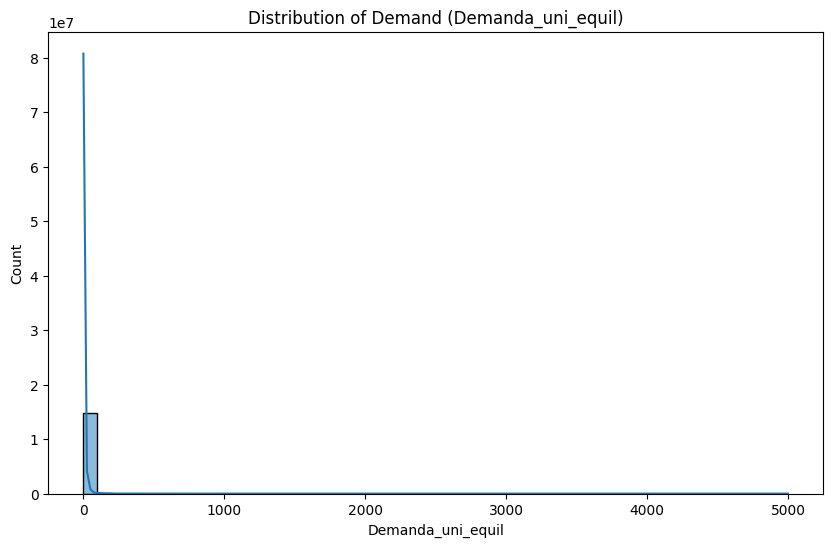

In [ ]:
try:
    dataraw = pd.read_csv('train.csv') 
except FileNotFoundError:
    print("Error: Dataset not found. Download it from Kaggle or check the path.")

# Subset data (20% for simulation)
dataraw = dataraw.sample(frac=0.2, random_state=42).copy() 

# Clean data
def clean_data(dataraw):
    dataraw = dataraw.copy()
    dataraw['Dev_uni_proxima'] = dataraw['Dev_uni_proxima'].fillna(0)
    dataraw['Dev_proxima'] = dataraw['Dev_proxima'].fillna(0.0)
    
    # Remove extreme outliers
    dataraw = dataraw[dataraw['Demanda_uni_equil'] < 1_000_000]
    return dataraw

dataraw = clean_data(dataraw)

# Feature engineering 
def engineer_features(dataraw):
    # Fix: Sort and group without inplace
    dataraw = dataraw.sort_values(['Cliente_ID', 'Producto_ID', 'Semana']).copy()
    dataraw['Lag1_Demanda'] = dataraw.groupby(['Cliente_ID', 'Producto_ID'])['Demanda_uni_equil'].shift(1)
    dataraw['Lag1_Demanda'] = dataraw['Lag1_Demanda'].fillna(0)  # Avoid inplace
    
    # Aggregated features (mean demand by product)
    dataraw['Mean_Demanda_Producto'] = dataraw.groupby('Producto_ID')['Demanda_uni_equil'].transform('mean')
    
    # One-hot encode categorical variables (e.g., Canal_ID)
    dataraw = pd.get_dummies(dataraw, columns=['Canal_ID'], drop_first=True)
    return dataraw

dataraw = engineer_features(dataraw)

# Summarize data
print("Data Overview:")
print(dataraw.info())
print("\nDescriptive Statistics:")
print(dataraw.describe())

# Plot demand distribution
plt.figure(figsize=(10, 6))
sns.histplot(dataraw['Demanda_uni_equil'], bins=50, kde=True)
plt.title('Distribution of Demand (Demanda_uni_equil)')
plt.show()

## 2. Model Training
**Objective:**
- Train an XGBoost (regression) model to predict `Demanda_uni_equil`.
- Validate performance with RMSE on a holdout set (weeks 8-9).

In [4]:
# Define features and target
features = ['Semana', 'Ruta_SAK', 'Venta_uni_hoy', 'Venta_hoy', 
            'Dev_uni_proxima', 'Dev_proxima', 'Lag1_Demanda', 
            'Mean_Demanda_Producto'] + [col for col in dataraw.columns if 'Canal_ID_' in col]
target = 'Demanda_uni_equil'

# Split data into train/test (simulate weekly batches)
train = dataraw[dataraw['Semana'] < 8]  # Weeks 3-7 for training
test = dataraw[dataraw['Semana'] >= 8]   # Weeks 8-9 for testing

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# Train XGBoost model
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")

RMSE: 11.12


## 3. Chaos Simulation
**Objective:**
- Introduce Gaussian noise and missing data to simulate realistic conditions.
- Measure the impact on RMSE (performance degradation).

In [5]:
def chaos_test(df, noise_level=0.2, missing_frac=0.1):
    # Add Gaussian noise to demand
    noisy_df = df.copy()
    noisy_df['Demanda_uni_equil'] *= (1 + noise_level * np.random.randn(len(df)))
    
    # Randomly drop rows (simulate missing data)
    noisy_df = noisy_df.sample(frac=1 - missing_frac, random_state=42)
    return noisy_df

noisy_test = chaos_test(test)
X_noisy, y_noisy = noisy_test[features], noisy_test[target]

# Evaluate on noisy data
y_pred_noisy = model.predict(X_noisy)
rmse_noisy = np.sqrt(mean_squared_error(y_noisy, y_pred_noisy))
print(f"RMSE (Noisy Data): {rmse_noisy:.2f}")

# Compare with baseline
print(f"Performance Drop: {((rmse_noisy - rmse) / rmse * 100):.1f}%")

RMSE (Noisy Data): 12.69
Performance Drop: 14.1%


## Visualization of Results
**Objective:**
- To show the importance of features.
- Compare predictions vs. actual values.

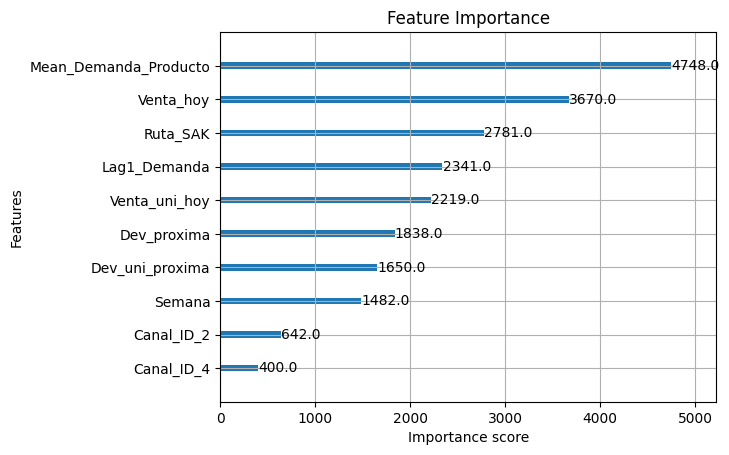

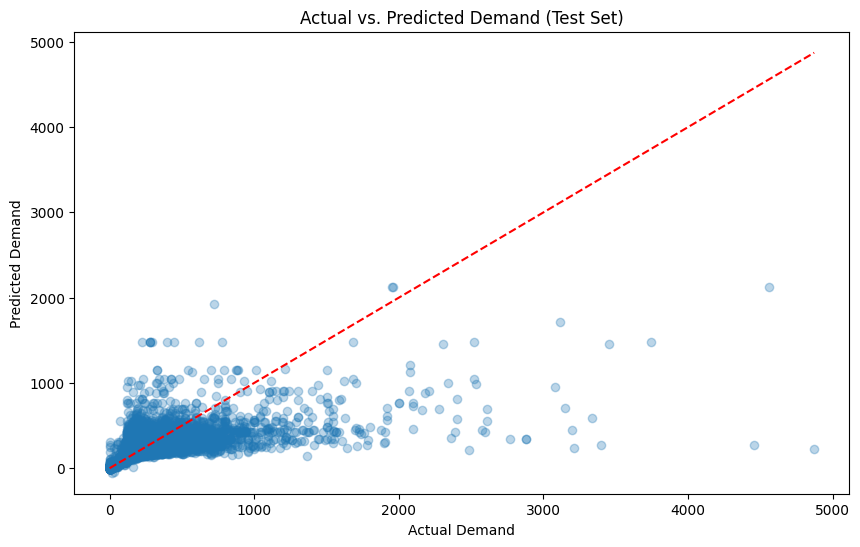

In [6]:
# Plot feature importance
xgb.plot_importance(model, max_num_features=10)
plt.title('Feature Importance')
plt.show()

# Plot actual vs. predicted demand
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Actual vs. Predicted Demand (Test Set)')
plt.show()

## Export of Results

In [10]:
import pickle
with open("ourFirstModel.pkl", "wb") as file:
    pickle.dump(model, file)

results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results.to_csv('simulation_results.csv', index=False)

report = f"""
Simulation Report - Grupo Bimbo Demand Forecasting
------------------------------------------------
1. Data Preparation:
   - Cleaned dataset with {len(dataraw)} records.
   - Engineered features: Lag1_Demanda, Mean_Demanda_Producto.

2. Model Performance:
   - Baseline RMSE: {rmse:.2f}
   - Noisy Data RMSE: {rmse_noisy:.2f}
   - Performance drop under chaos: {((rmse_noisy - rmse) / rmse * 100):.1f}%

3. Key Insights:
   - Top features: 'Mean_Demanda_Producto', 'Lag1_Demanda'.
   - System handled noise but with degraded accuracy.
"""

with open('simulation_report.txt', 'w') as f:
    f.write(report)